Dataset Shape: (20640, 9)

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


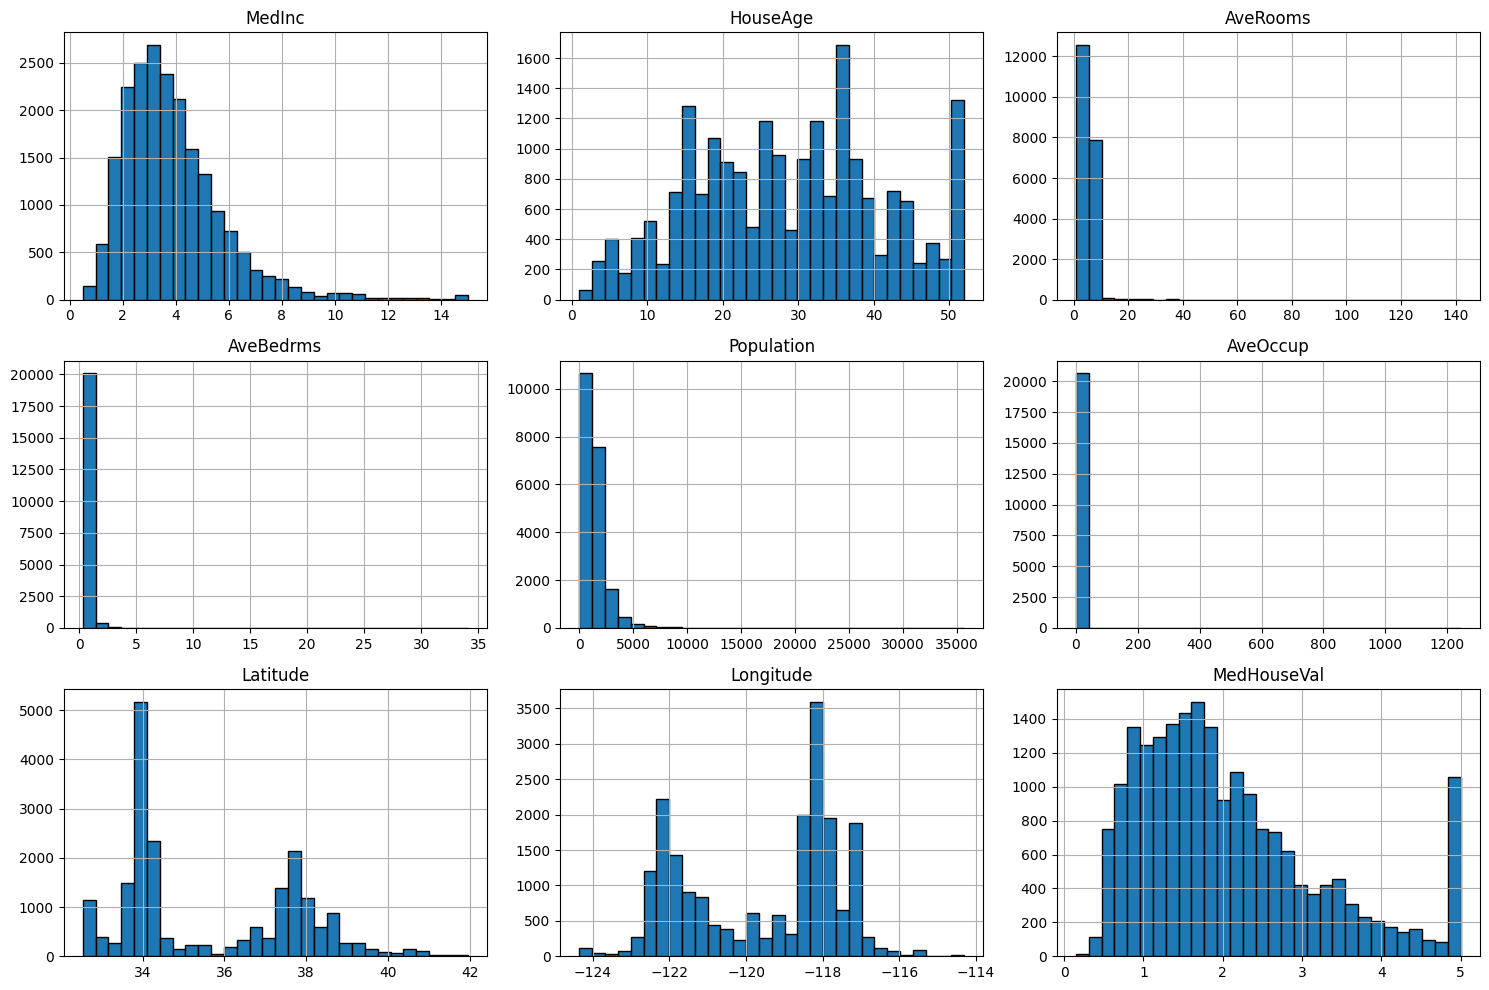

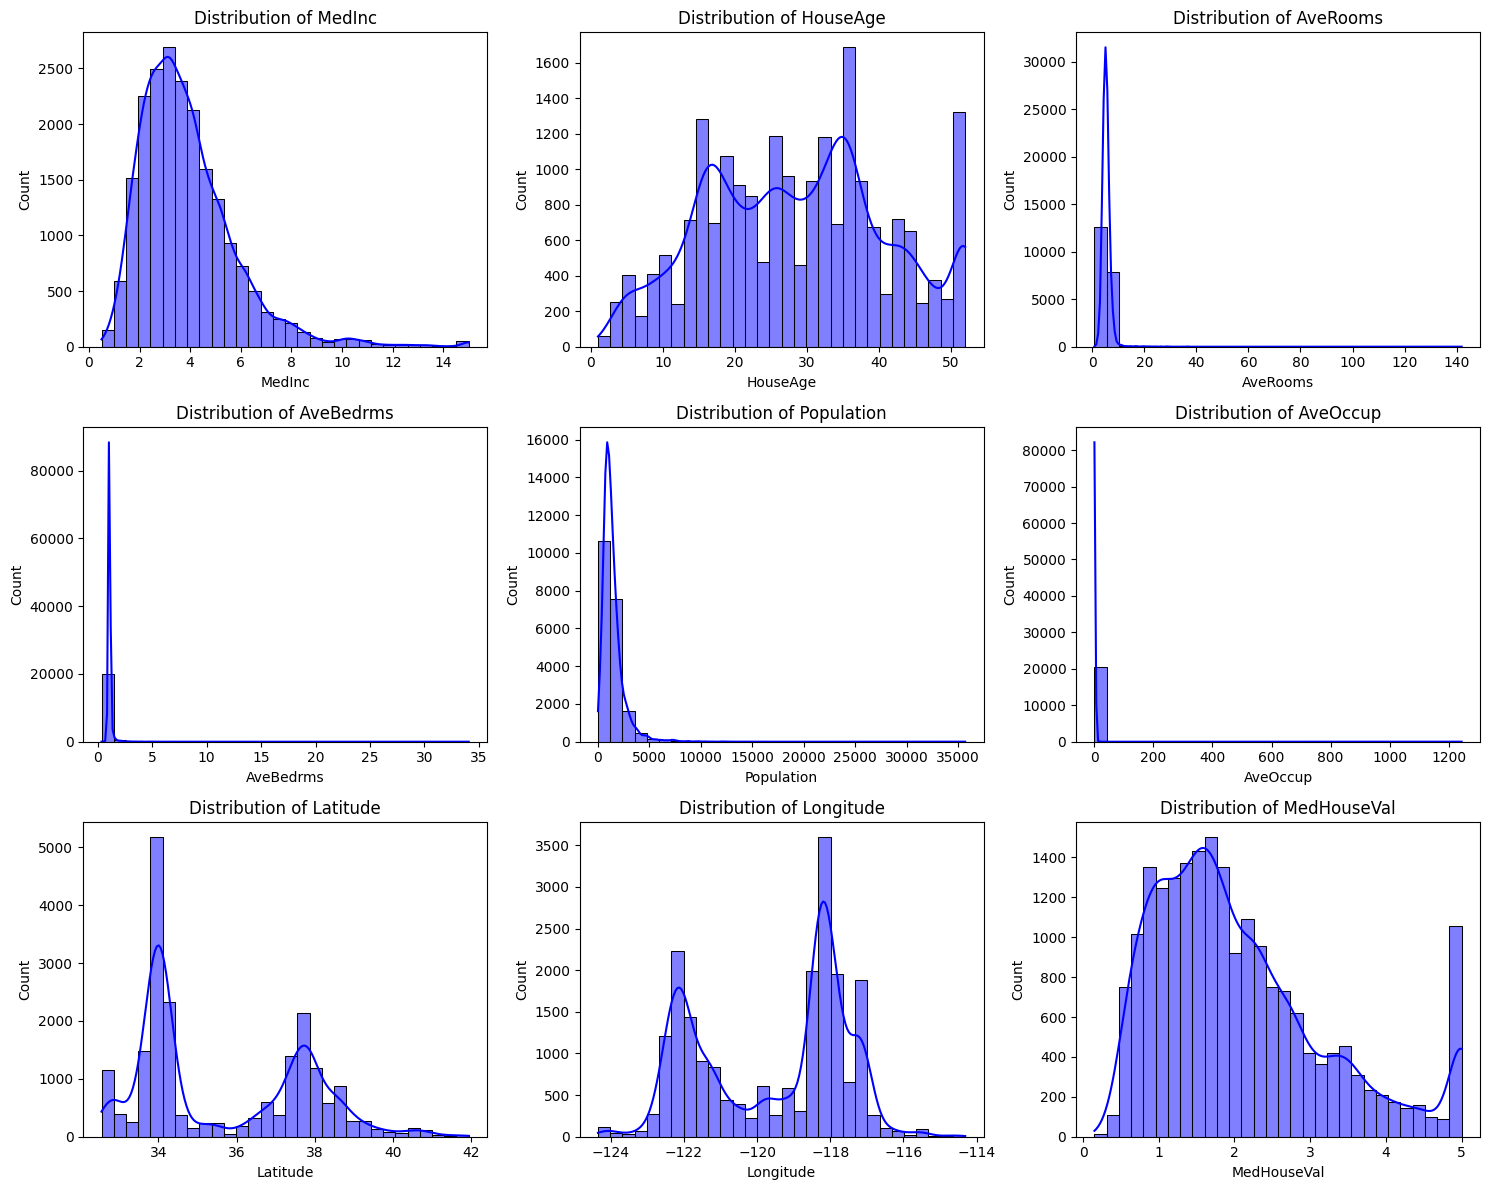

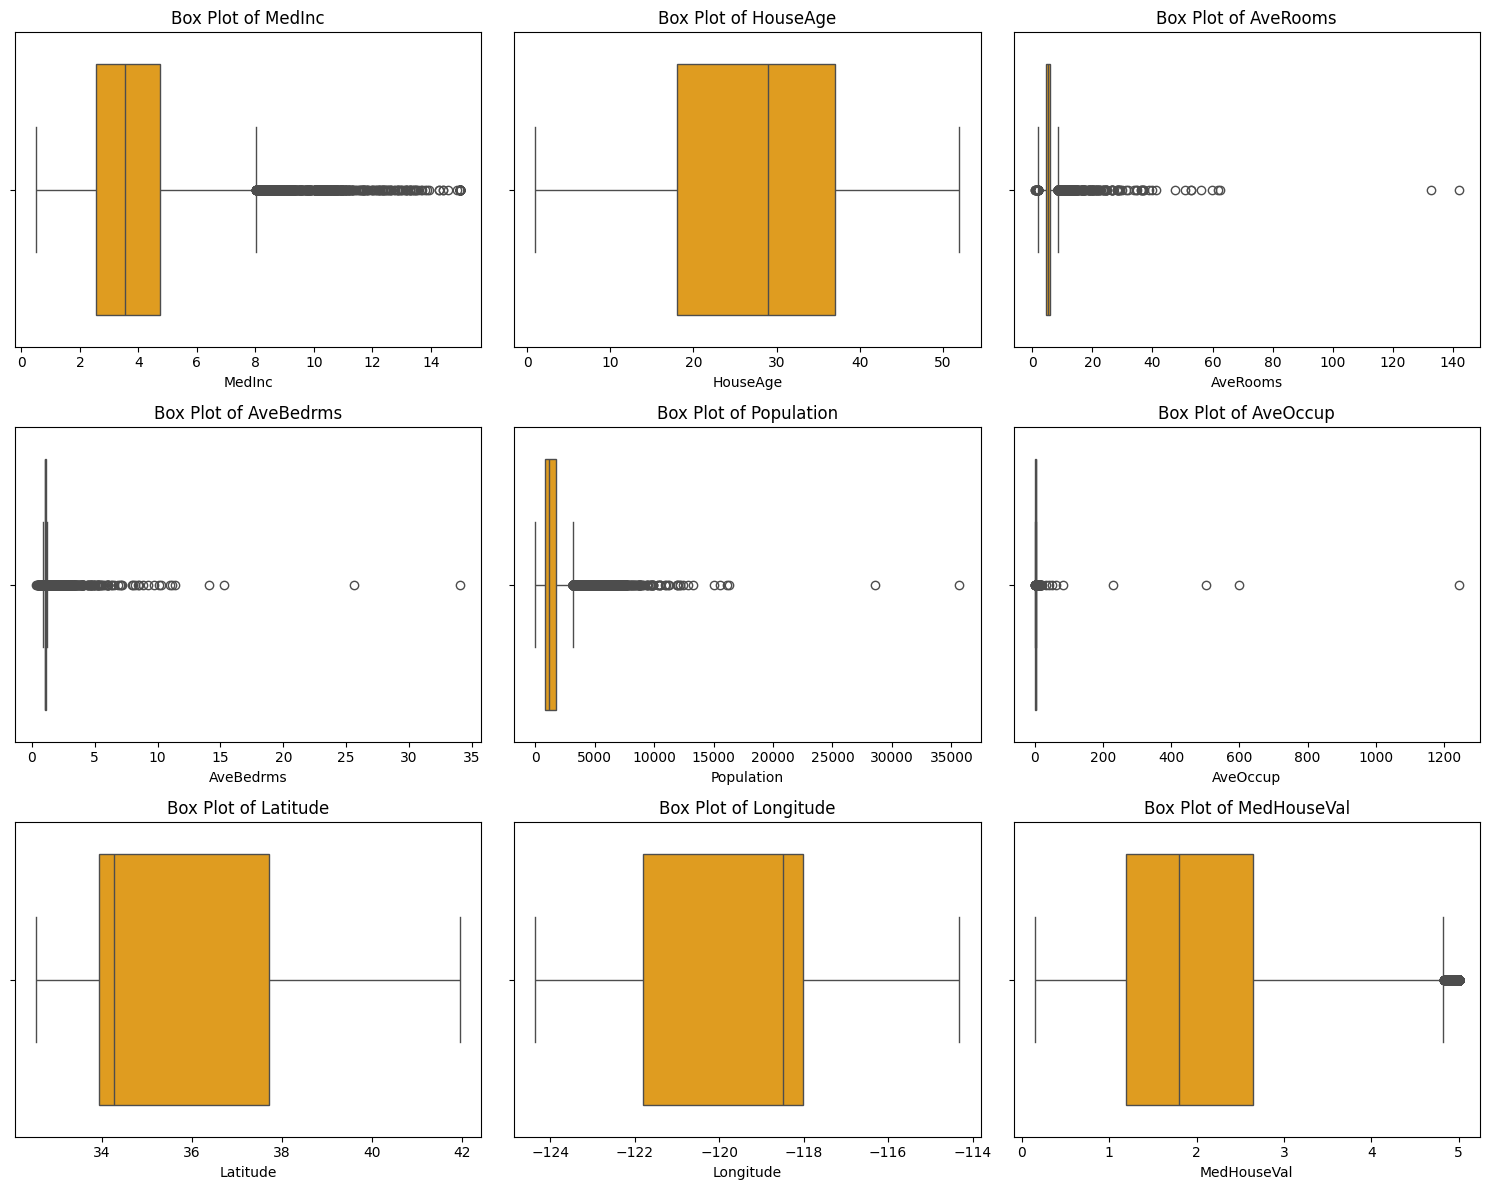


=== Outliers Detection (IQR Method) ===
MedInc                   :  681 outliers ( 3.30%)
HouseAge                 :    0 outliers ( 0.00%)
AveRooms                 :  511 outliers ( 2.48%)
AveBedrms                : 1424 outliers ( 6.90%)
Population               : 1196 outliers ( 5.79%)
AveOccup                 :  711 outliers ( 3.44%)
Latitude                 :    0 outliers ( 0.00%)
Longitude                :    0 outliers ( 0.00%)
MedHouseVal              : 1071 outliers ( 5.19%)

=== Dataset Summary ===
           MedInc    HouseAge    AveRooms   AveBedrms  Population    AveOccup  \
count  20640.0000  20640.0000  20640.0000  20640.0000  20640.0000  20640.0000   
mean       3.8707     28.6395      5.4290      1.0967   1425.4767      3.0707   
std        1.8998     12.5856      2.4742      0.4739   1132.4621     10.3860   
min        0.4999      1.0000      0.8462      0.3333      3.0000      0.6923   
25%        2.5634     18.0000      4.4407      1.0061    787.0000      2.4297  

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Step 1: Load the dataset
data = fetch_california_housing(as_frame=True)
housing_df = data.frame

print("Dataset Shape:", housing_df.shape)
print("\nColumns:", housing_df.columns.tolist())

# Step 2: Basic histograms (pandas built-in)
housing_df.hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

# Step 3: Enhanced histograms with KDE using seaborn
numerical_features = housing_df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(housing_df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

# Step 4: Box plots
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=housing_df[feature], color='orange')
    plt.title(f'Box Plot of {feature}')

plt.tight_layout()
plt.show()

# Step 5: Outlier detection using IQR method
print("\n=== Outliers Detection (IQR Method) ===")
outliers_summary = {}
for feature in numerical_features:
    Q1 = housing_df[feature].quantile(0.25)
    Q3 = housing_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = housing_df[(housing_df[feature] < lower_bound) | 
                         (housing_df[feature] > upper_bound)]
    outliers_summary[feature] = len(outliers)
    print(f"{feature:25}: {len(outliers):4} outliers "
          f"({len(outliers)/len(housing_df)*100:5.2f}%)")

# Step 6: Dataset summary
print("\n=== Dataset Summary ===")
print(housing_df.describe().round(4))

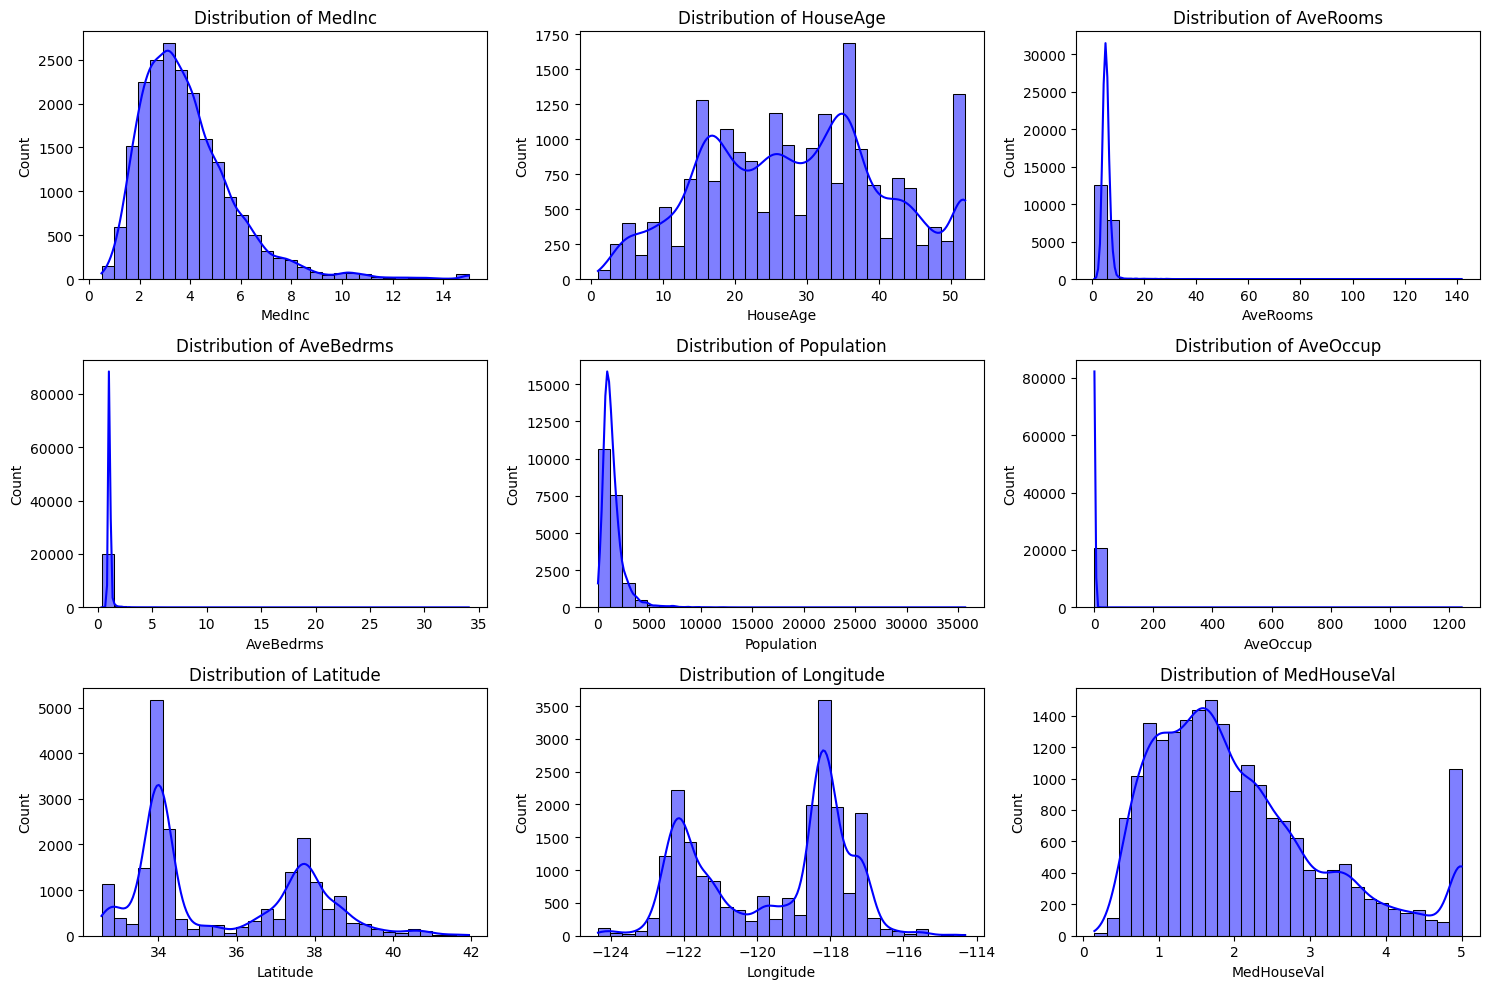

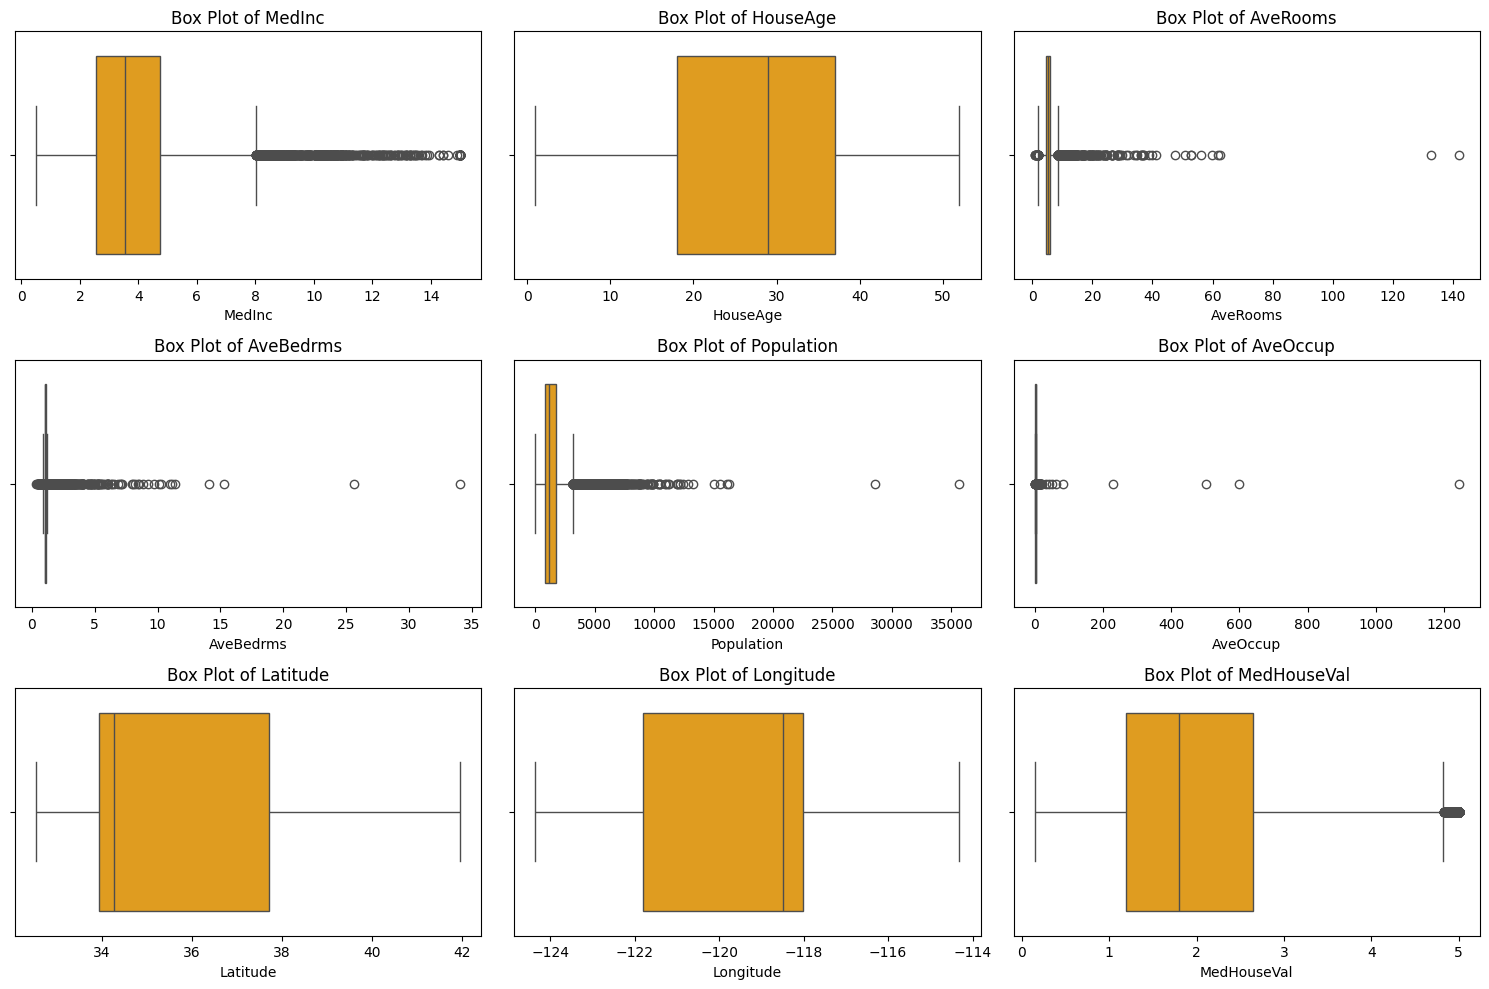

Outliers Detection:
MedInc: 681 outliers
HouseAge: 0 outliers
AveRooms: 511 outliers
AveBedrms: 1424 outliers
Population: 1196 outliers
AveOccup: 711 outliers
Latitude: 0 outliers
Longitude: 0 outliers
MedHouseVal: 1071 outliers

Dataset Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Lon

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Step 1: Load the California Housing dataset
data = fetch_california_housing(as_frame=True)
housing_df = data.frame

# Step 2: Create histograms for numerical features
numerical_features = housing_df.select_dtypes(include=[np.number]).columns

# Plot histograms
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(housing_df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Step 3: Generate box plots for numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=housing_df[feature], color='orange')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

# Step 4: Identify outliers using the IQR method
print("Outliers Detection:")
outliers_summary = {}
for feature in numerical_features:
    Q1 = housing_df[feature].quantile(0.25)
    Q3 = housing_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = housing_df[(housing_df[feature] < lower_bound) | (housing_df[feature] > upper_bound)]
    outliers_summary[feature] = len(outliers)
    print(f"{feature}: {len(outliers)} outliers")

# Optional: Print a summary of the dataset
print("\nDataset Summary:")
print(housing_df.describe())
